<a href="https://colab.research.google.com/github/Abhinraj175/Markov-chain-/blob/main/Markov_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install pandas numpy matplotlib scipy

In [ ]:
#Load rainfall dataset
import pandas as pd

# load csv
rain = pd.read_csv("/content/drive/MyDrive/Markov chain/kuttanad_rainfall.csv")

# convert date column
rain['Date'] = pd.to_datetime(rain['Date'])

# sort data
rain = rain.sort_values("Date")

print(rain.head())

        Date   Rainfall  Unnamed: 2  Unnamed: 3  Unnamed: 4  \
0 1990-01-01   0.000000         NaN         NaN         NaN   
1 1990-01-02   0.625894         NaN         NaN         NaN   
2 1990-01-03  22.564243         NaN         NaN         NaN   
3 1990-01-04   0.000000         NaN         NaN         NaN   
4 1990-01-05   0.000000         NaN         NaN         NaN   

   Lat: 9.5000, Lon: 76.5000  
0                        NaN  
1                        NaN  
2                        NaN  
3                        NaN  
4                        NaN  


In [ ]:
#Convert rainfall to wet/dry states
rain['state'] = (rain['Rainfall'] >= 1).astype(int)
rain['state'].value_counts()

,count
state,
0,5903
1,5420


In [ ]:
#Calculate transition probabilities
import numpy as np

states = rain['state'].values

DD = DW = WD = WW = 0

for i in range(len(states)-1):

    if states[i] == 0 and states[i+1] == 0:
        DD += 1

    elif states[i] == 0 and states[i+1] == 1:
        DW += 1

    elif states[i] == 1 and states[i+1] == 0:
        WD += 1

    elif states[i] == 1 and states[i+1] == 1:
        WW += 1

In [ ]:
#Compute probabilities
Pdd = DD / (DD + DW)
Pdw = DW / (DD + DW)

Pwd = WD / (WD + WW)
Pww = WW / (WD + WW)

print("Transition Matrix")

print([[Pdd, Pdw],
       [Pwd, Pww]])

Transition Matrix
[[0.7780789429103846, 0.22192105708961546], [0.24155748293042997, 0.75844251706957]]


In [ ]:
#Fit rainfall distribution (for wet days)
from scipy.stats import gamma

wet_rain = rain[rain['Rainfall'] >= 1]['Rainfall']

shape, loc, scale = gamma.fit(wet_rain, floc=0)

print(shape, loc, scale)

1.0906925948817998 0 15.216965463111514


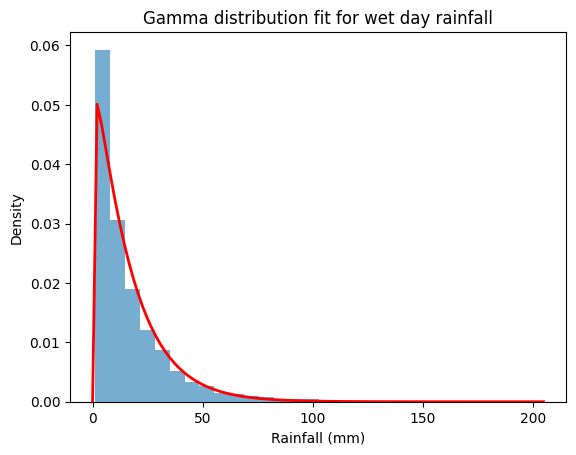

In [ ]:
#Plot distribution fit
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(0, wet_rain.max(), 100)

pdf = gamma.pdf(x, shape, loc, scale)

plt.hist(wet_rain, bins=30, density=True, alpha=0.6)
plt.plot(x, pdf, 'r', linewidth=2)

plt.title("Gamma distribution fit for wet day rainfall")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Density")
plt.show()

In [ ]:
#Simulate wet/dry rainfall sequence
sim_states = []

state = np.random.choice([0,1])

for i in range(10000):

    if state == 0:
        state = np.random.choice([0,1], p=[Pdd, Pdw])

    else:
        state = np.random.choice([0,1], p=[Pwd, Pww])

    sim_states.append(state)

In [ ]:
#Generate rainfall amounts
sim_rain = []

for s in sim_states:

    if s == 1:
        r = gamma.rvs(shape, loc, scale)
    else:
        r = 0

    sim_rain.append(r)

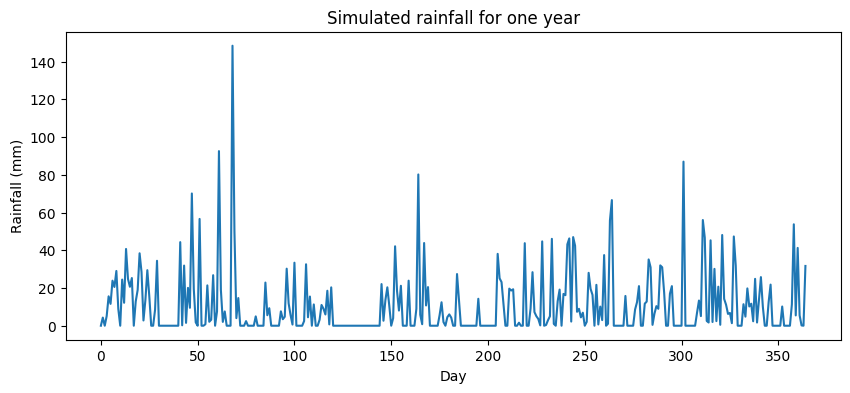

In [ ]:
#Plot synthetic rainfall
plt.figure(figsize=(10,4))

plt.plot(sim_rain[:365])

plt.title("Simulated rainfall for one year")
plt.xlabel("Day")
plt.ylabel("Rainfall (mm)")

plt.show()

In [ ]:
#Compare observed vs simulated statistics
print("Observed mean rainfall:", rain['Rainfall'].mean())
print("Simulated mean rainfall:", np.mean(sim_rain))

print("Observed wet days:", (rain['Rainfall']>=1).mean())
print("Simulated wet days:", np.mean(sim_states))

Observed mean rainfall: 7.982060258843681
Simulated mean rainfall: 8.139853396731036
Observed wet days: 0.47867173010686215
Simulated wet days: 0.4903


In [ ]:
#Save synthetic rainfall
sim_df = pd.DataFrame({
    "Rainfall": sim_rain
})

sim_df.to_csv("synthetic_rainfall.csv", index=False)